# SDM in Python

Some features based on https://github.com/daniel-furman/eco-distribution-mapping/blob/main/Python-sdm.ipynb

### Generate Pseudo-Absence Data
Absence data must be generated for these classifiers, and different quantities must be generated for types of classifiers, based on Barbet-Massin et al., 2012.

### Making subdirectories
inputs - files input for processing   
outputs - results from processing

In [21]:
import os
# os.mkdir("inputs", ex)
# os.mkdir("outputs")
import subprocess
from sklearn.ensemble import RandomForestClassifier
# from sklearn.ensemble import ExtraTreesClassifier 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from pygam import GAM, s, f
from sklearn.tree import DecisionTreeClassifier
# out of all the glms, we choose the poisson - it does not have negative values, and varying variance???
# also we are looking for a scale of values up to 1000...
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from pyimpute import impute
from sklearn import model_selection
from elapid import MaxentModel

Run the subprocess, R code to generate pseudo absences. Will be customized depending on the models

In [10]:
command = ["C:\\Users\\chenst-intern\\AppData\\Local\\Programs\\R\\R-4.6.1\\bin\\x64\\Rscript.exe",'pseudo_absence.R', 
           'pests\\northern_corn_rootworm_0003360-260623161305970\\ncr.csv', "2", "northerncorn"]
subprocess.run(command, check = True)

CompletedProcess(args=['C:\\Users\\chenst-intern\\AppData\\Local\\Programs\\R\\R-4.6.1\\bin\\x64\\Rscript.exe', 'pseudo_absence.R', 'pests\\northern_corn_rootworm_0003360-260623161305970\\ncr.csv', '2', 'northerncorn'], returncode=0)

### Converting shapefiles (.shp) to geopandas dataframe

In [11]:
import geopandas as gpd
import shutil
import glob

# for f in sorted(glob.glob('data/ncr*')):
#     shutil.copy(f, 'inputs/')

ncr_gdf = gpd.GeoDataFrame.from_file('data/ncr.shp')
ncr_gdf.sample(5)

,CLASS,geometry
1018,1.0,POINT (-91.55901 41.63619)
247,0.0,POINT (-104.01038 48.82585)
1089,1.0,POINT (-96.76211 46.9122)
503,1.0,POINT (-93.21497 44.93049)
417,1.0,POINT (-88.64811 44.08946)


Checking duplicates and NA values. Coordinate reference system should ideally be epsg: 4326

In [12]:
print("Number of duplicates: ", ncr_gdf.duplicated(subset='geometry', keep='first').sum())
print("Number of NA's: ", ncr_gdf['geometry'].isna().sum())
print("Coordinate reference system: {}".format(ncr_gdf.crs))
print("{} observations with {} columns".format(*ncr_gdf.shape))

Number of duplicates:  0
Number of NA's:  0
Coordinate reference system: GEOGCS["unknown",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
1222 observations with 2 columns


Mapping the species presences (pa == 1)

<Axes: >

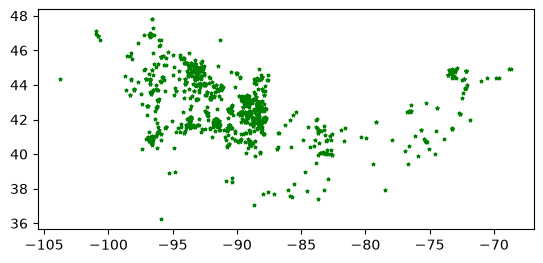

In [13]:
ncr_gdf[ncr_gdf.CLASS == 1].plot(marker='*', color='green', markersize=5)

Mapping the species absences (pa == 0)

<Axes: >

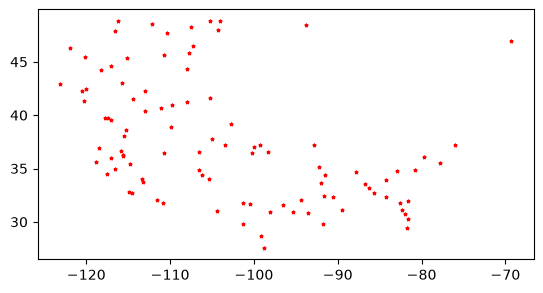

In [14]:
ncr_gdf[ncr_gdf.CLASS == 0].plot(marker='*', color='red', markersize=5)

### Classifier Training

In [15]:
# TO MOVE FILES INTO INPUT
# for f in sorted(glob.glob('worldclim/wc2.1_2.5m_bio_*.tif')):
#     shutil.copy(f,'inputs/')

ras_feats = sorted(glob.glob(
    'worldclim/wc2.1_2.5m_bio_*.tif'))

print('There are ', len(ras_feats), ' raster features.')


There are  7  raster features.


Generate raster maps of suitability. Also separate test sets from the rest for cross validation

In [ ]:
from pyimpute import load_training_vector
from pyimpute import load_targets

train_xs, train_ys = load_training_vector(ncr_gdf, ras_feats, response_field='CLASS')
train_x, test_x, train_y, test_y = model_selection.train_test_split(train_xs, train_ys, test_size=0.25, random_state=42)
target_xs, raster_info = load_targets(ras_feats)
# train_xs.shape, train_ys.shape
train_x.shape, test_x.shape, train_y.shape, test_y.shape

((916, 7), (306, 7), (916,), (306,))

Classifier implementation

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
CLASS_MAP = {
    'rf': (RandomForestClassifier()),
    # 'et': (ExtraTreesClassifier()),
    'lda': (LinearDiscriminantAnalysis()),
    'dtc': (DecisionTreeClassifier()),
    'glm': (LogisticRegression()),
    'xgb': (XGBClassifier()),
    'lgbm': (LGBMClassifier()),
    # 'maxent': (MaxentModel())
}

ALT_MAP = {
    'gam': (GAM()),
}

sample_weights = compute_sample_weight(class_weight='balanced', y=train_y)

for name, (model) in CLASS_MAP.items():
    # cross validation for accuracy scores (displayed as a percentage)
    k = 4 # k-fold
    kf = model_selection.KFold(n_splits=k, shuffle=True, random_state=42)
    accuracy_scores = model_selection.cross_val_score(model, train_x, train_y, cv=kf, scoring='accuracy')
    print(name + " %d-fold Cross Validation Accuracy: %0.2f (+/- %0.2f)"
          % (k, accuracy_scores.mean() * 100, accuracy_scores.std() * 200))
    
    # spatial prediction
    model.fit(train_x, train_y)
    # os.mkdir('outputs/' + name + '-images')
    score = model.score(test_x, test_y)
    print(name + " score: %f" % (score))
    impute(target_xs, model, raster_info, outdir='outputs/' + name + '-images',
           class_prob=True, certainty=True)

rf 4-fold Cross Validation Accuracy: 99.34 (+/- 0.98)
rf score: 0.996732
lda 4-fold Cross Validation Accuracy: 98.80 (+/- 0.72)
lda score: 0.993464
dtc 4-fold Cross Validation Accuracy: 98.80 (+/- 1.29)
dtc score: 0.986928
xgb 4-fold Cross Validation Accuracy: 98.47 (+/- 1.45)
xgb score: 0.996732
[LightGBM] [Info] Number of positive: 635, number of negative: 52
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000152 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1263
[LightGBM] [Info] Number of data points in the train set: 687, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.924309 -> initscore=2.502381
[LightGBM] [Info] Start training from score 2.502381
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

c:\Users\chenst-intern\OneDrive - World Wildlife Fund, Inc\Documents\sdm\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\chenst-intern\OneDrive - World Wildlife Fund, Inc\Documents\sdm\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\chenst-intern\OneDrive - World Wildlife Fund, Inc\Documents\sdm\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

c:\Users\chenst-intern\OneDrive - World Wildlife Fund, Inc\Documents\sdm\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\chenst-intern\OneDrive - World Wildlife Fund, Inc\Documents\sdm\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\chenst-intern\OneDrive - World Wildlife Fund, Inc\Documents\sdm\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


lgbm 4-fold Cross Validation Accuracy: 99.13 (+/- 1.07)
[LightGBM] [Info] Number of positive: 841, number of negative: 75
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000139 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1405
[LightGBM] [Info] Number of data points in the train set: 916, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.918122 -> initscore=2.417104
[LightGBM] [Info] Start training from score 2.417104
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM]

c:\Users\chenst-intern\OneDrive - World Wildlife Fund, Inc\Documents\sdm\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\chenst-intern\OneDrive - World Wildlife Fund, Inc\Documents\sdm\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\chenst-intern\OneDrive - World Wildlife Fund, Inc\Documents\sdm\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\chenst-intern\OneDrive - World Wildlife Fund, Inc\Documents\sdm\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\che

Averaging the outputs of the models, and plotting it onto a map

C:\Users\chenst-intern\AppData\Local\Temp\ipykernel_15036\1924409663.py:9: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  distr_rf = rasterio.open("outputs/rf-images/probability_1.0.tif").read(1)
C:\Users\chenst-intern\AppData\Local\Temp\ipykernel_15036\1924409663.py:10: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  distr_et = rasterio.open("outputs/et-images/probability_1.0.tif").read(1)
C:\Users\chenst-intern\AppData\Local\Temp\ipykernel_15036\1924409663.py:11: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  distr_xgb =  rasterio.open("outputs/xgb-images/probability_1.tif").read(1)
C:\U

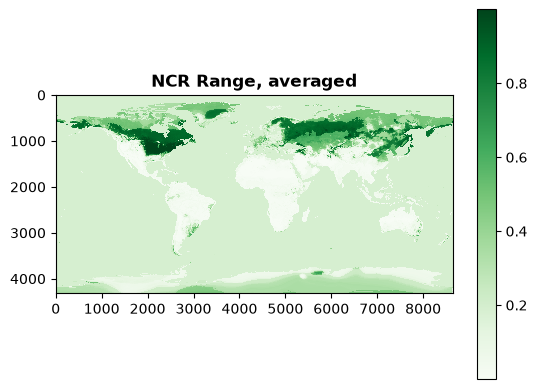

In [ ]:
from pylab import plt
# define spatial plotter
def plotit(x, title, cmap="Blues"):
    plt.imshow(x, cmap=cmap, interpolation='nearest')
    plt.colorbar()
    plt.title(title, fontweight = 'bold')

import rasterio
distr_rf = rasterio.open("outputs/rf-images/probability_1.0.tif").read(1)
distr_et = rasterio.open("outputs/et-images/probability_1.0.tif").read(1)
distr_xgb =  rasterio.open("outputs/xgb-images/probability_1.tif").read(1)
distr_lgbm =  rasterio.open("outputs/lgbm-images/probability_1.0.tif").read(1)
distr_averaged = (distr_rf + distr_et + distr_xgb + distr_lgbm)/4  

plotit(distr_averaged, "NCR Range, averaged", cmap="Greens")